
 # 📚 Book Data  Analytics

*This project analyzes a synthetic publishing dataset using Python to uncover insights into book performance, reader preferences, author success, publisher trends, and genre popularity. The objective is to perform exploratory data analysis (EDA) and generate meaningful business insights through data visualization and statistical analysis.*

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** `books.csv`

---


## 1) Import Libraries and Load Dataset

In [147]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

books = pd.read_csv(r"C:\Users\annej\OneDrive\Desktop\books.csv")


In [148]:
books.head(3)

,book_id,title,author_id,publisher_id,primary_genre,secondary_genre,language,country,publication_year,pages,...,to_read_count,popularity_score,awards_won,price_usd,is_series,series_number,format,reading_difficulty,sentiment_score,description
0,1,Letters from the Wild House,3882,127,Historical Fiction,NaN,English,United States,2025,433,...,2566,100,0,19.75,True,1.0,Paperback,Moderate,0.60,"A historical fiction book exploring history, f..."
1,2,A Broken Promise,1269,139,Biography,NaN,English,United States,1994,460,...,206,46,0,17.96,False,NaN,Paperback,Easy,0.49,"A biography book exploring artist, legacy, and..."
2,3,The Last Fire of Kyoto,232,182,Mystery,NaN,Korean,Canada,2000,378,...,23455,100,0,10.68,False,NaN,Paperback,Moderate,0.40,"A mystery book exploring cold case, secrets, a..."


## 2) Dataset Overview
*Before analysis, we inspect the size, columns, missing values, duplicates, and basic statistics of the dataset.*

In [149]:
# dataset.shape - gives output as tuple in form of ((number_of_rows, number_of_columns))
# dataset.columns - given output as a list and gives all the names of the columns 

print("Dataset Shape ",books.shape)
print()
print("Columns: ",books.columns)
print()

Dataset Shape  (30000, 23)

Columns:  Index(['book_id', 'title', 'author_id', 'publisher_id', 'primary_genre',
       'secondary_genre', 'language', 'country', 'publication_year', 'pages',
       'average_rating', 'rating_count', 'review_count', 'to_read_count',
       'popularity_score', 'awards_won', 'price_usd', 'is_series',
       'series_number', 'format', 'reading_difficulty', 'sentiment_score',
       'description'],
      dtype='str')



In [150]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   book_id             30000 non-null  int64  
 1   title               30000 non-null  str    
 2   author_id           30000 non-null  int64  
 3   publisher_id        30000 non-null  int64  
 4   primary_genre       30000 non-null  str    
 5   secondary_genre     11465 non-null  str    
 6   language            30000 non-null  str    
 7   country             30000 non-null  str    
 8   publication_year    30000 non-null  int64  
 9   pages               30000 non-null  int64  
 10  average_rating      30000 non-null  float64
 11  rating_count        30000 non-null  int64  
 12  review_count        30000 non-null  int64  
 13  to_read_count       30000 non-null  int64  
 14  popularity_score    30000 non-null  int64  
 15  awards_won          30000 non-null  int64  
 16  price_usd      

In [151]:
# check whether duplicates or missing values exist in the dataset 

# to check whether there are any missing values at all - output as true of false -- syntax- dataset.isnull().values.any()
any_missing_value = books.isnull().values.any()
print(any_missing_value)

print("-------------------------------------------------------------")

# to check if null values exist in particular columns- output as sum 
missing_values = books.isnull().sum()
print(missing_values)



True
-------------------------------------------------------------
book_id                   0
title                     0
author_id                 0
publisher_id              0
primary_genre             0
secondary_genre       18535
language                  0
country                   0
publication_year          0
pages                     0
average_rating            0
rating_count              0
review_count              0
to_read_count             0
popularity_score          0
awards_won                0
price_usd                 0
is_series                 0
series_number         21489
format                    0
reading_difficulty        0
sentiment_score           0
description               0
dtype: int64


In [152]:
# to check if duplicates exist 
# dataset.duplicated().sum()

duplicates = books.duplicated().sum()
print(duplicates)

0


In [153]:
# if duplicates exist and we want to remive them - 
# dataset.drop_duplicates()

books.drop_duplicates(inplace =True)

# no duplicates exist so no output

In [154]:
# .describe() uses the numpy library and gives overall statistics of the dataset such as count , mean, std, min, max , 25%, 50%, 75%

books.describe()

,book_id,author_id,publisher_id,publication_year,pages,average_rating,rating_count,review_count,to_read_count,popularity_score,awards_won,price_usd,series_number,sentiment_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,8511.000000,30000.000000
mean,15000.500000,2002.519133,124.740833,2005.863533,373.768267,4.004622,14603.622600,1422.225300,6086.546200,80.245233,0.412800,16.443883,4.515803,0.499703
std,8660.398374,1157.977701,72.074054,19.530391,97.421281,0.330076,19855.659226,2101.323556,9592.332767,17.966754,1.465447,4.161841,2.299329,0.239760
min,1.000000,1.000000,1.000000,1850.000000,80.000000,2.520000,124.000000,7.000000,21.000000,5.000000,0.000000,3.990000,1.000000,-0.550000
25%,7500.750000,999.000000,63.000000,1999.000000,316.000000,3.780000,4295.750000,367.000000,1421.000000,68.000000,0.000000,13.630000,2.000000,0.340000
50%,15000.500000,1994.000000,125.000000,2009.000000,368.000000,4.000000,8624.000000,785.000000,3166.500000,83.000000,0.000000,16.450000,5.000000,0.500000
75%,22500.250000,3006.000000,187.000000,2017.000000,429.000000,4.230000,17252.250000,1643.000000,6923.250000,98.000000,0.000000,19.230000,7.000000,0.670000
max,30000.000000,4000.000000,250.000000,2025.000000,720.000000,4.950000,656425.000000,46392.000000,224080.000000,100.000000,8.000000,34.270000,8.000000,1.000000


## 3) Data Cleaning 


In [155]:
# drop the unnecessary column of secondary genre

books = books.drop('secondary_genre', axis=1)

In [156]:
books.iloc[0:2]

,book_id,title,author_id,publisher_id,primary_genre,language,country,publication_year,pages,average_rating,...,to_read_count,popularity_score,awards_won,price_usd,is_series,series_number,format,reading_difficulty,sentiment_score,description
0,1,Letters from the Wild House,3882,127,Historical Fiction,English,United States,2025,433,4.32,...,2566,100,0,19.75,True,1.0,Paperback,Moderate,0.60,"A historical fiction book exploring history, f..."
1,2,A Broken Promise,1269,139,Biography,English,United States,1994,460,4.10,...,206,46,0,17.96,False,NaN,Paperback,Easy,0.49,"A biography book exploring artist, legacy, and..."


In [157]:
# rename primary genre to only genre 
# to rename a column ->  dataset = dataset.rename(columns={'old_columnname' : 'new column name'})

books = books.rename(columns={'primary_genre': 'genre'})

# 4) Exploratory Data Analysis

## a) Which Genres Have The Highest Number Of Books ?


In [158]:
# using groupby 

book_genre = books.groupby('genre')['title'].count()
book_genre

genre
Adventure             1288
Biography              768
Classics               776
Crime                 1611
Fantasy               2449
Graphic Novel          849
Historical Fiction    1837
Horror                1312
Literary Fiction      2062
Memoir                1065
Mystery               2436
Nonfiction            1702
Poetry                 571
Romance               3164
Science Fiction       1956
Self Help             1354
Thriller              2654
Young Adult           2146
Name: title, dtype: int64

In [159]:
# using pivot table

books_genre = books.pivot_table(index='genre' , values ='title', aggfunc= 'count').head().sort_values(by='title',ascending=False)
books_genre

,title
genre,
Fantasy,2449
Crime,1611
Adventure,1288
Classics,776
Biography,768


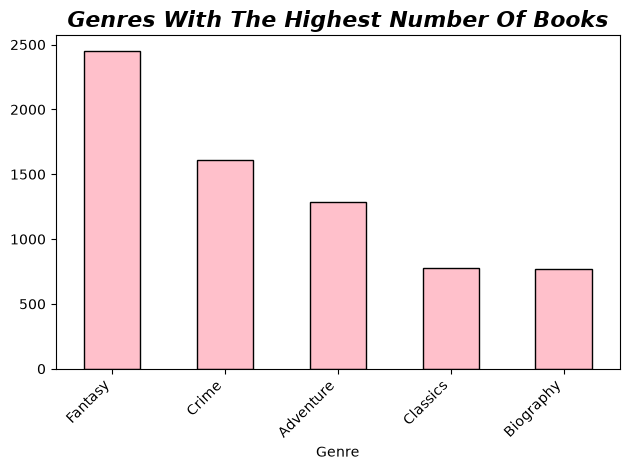

In [160]:
books_genre.plot( kind='bar' , legend=False ,color ='pink',edgecolor ='black')
plt.title("Genres With The Highest Number Of Books" ,fontsize=16,fontstyle='italic',fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('')
plt.xticks(rotation = 45 , ha='right')
plt.tight_layout()
plt.show()

## Question 2: Which genres perform best overall based on rating, popularity, reviews, and book count?

### This uses 4 columns:

primary_genre , 
average_rating , 
popularity_score , 
review_count , 
book_id

In [161]:
genre_performance = books.groupby('genre').agg(
    book_count=('book_id', 'count'),
    avg_rating=('average_rating', 'mean'),
    avg_popularity=('popularity_score', 'mean'),
    total_reviews=('review_count', 'sum')
).sort_values(by='avg_rating', ascending=False)

genre_performance

,book_count,avg_rating,avg_popularity,total_reviews
genre,,,,
Classics,776,4.167191,59.828608,843430
Historical Fiction,1837,4.155983,80.523136,2762157
Memoir,1065,4.131192,71.517371,1330135
Biography,768,4.090898,65.201823,834319
Nonfiction,1702,4.089718,70.543478,2093561
Fantasy,2449,4.089098,86.873009,3602714
Literary Fiction,2062,4.065946,75.998060,2744054
Science Fiction,1956,4.029652,79.372188,2786905
Mystery,2436,3.995866,83.772578,3572706


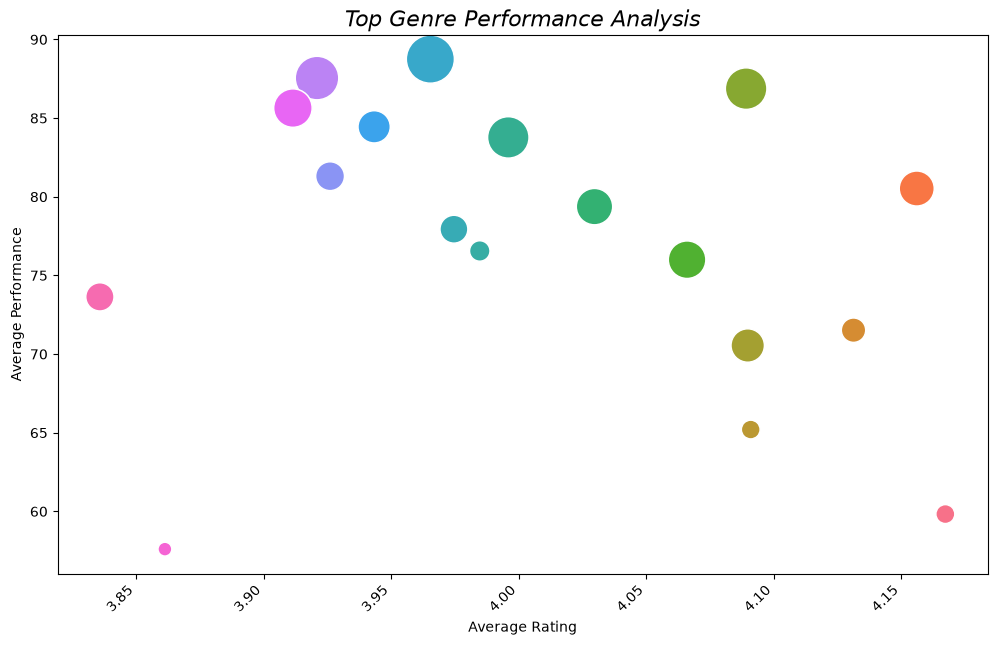

In [162]:
plt.figure(figsize = (12,7))

sns.scatterplot(
    data=genre_performance.reset_index(),
    x='avg_rating',
    y='avg_popularity',
    size='book_count',
    hue='genre',
    legend=False,
    sizes=(100, 1200),
)

plt.title("Top Genre Performance Analysis", fontsize=16, fontstyle='italic')
plt.xlabel('Average Rating')
plt.ylabel('Average Performance')
plt.xticks(rotation = 45 , ha='right')
plt.tight_layout
plt.show()

## Question 3 - Which publisher publishes the most books in each genre?

In [171]:
publisher = books.pivot_table(index='publisher_id',columns ='genre', values='book_id', aggfunc = 'count')
publisher

genre,Adventure,Biography,Classics,Crime,Fantasy,Graphic Novel,Historical Fiction,Horror,Literary Fiction,Memoir,Mystery,Nonfiction,Poetry,Romance,Science Fiction,Self Help,Thriller,Young Adult
publisher_id,,,,,,,,,,,,,,,,,,
1,5.0,7.0,4.0,5.0,12.0,4.0,6.0,3.0,8.0,7.0,11.0,9.0,1.0,26.0,9.0,3.0,7.0,7.0
2,4.0,4.0,3.0,10.0,8.0,3.0,4.0,9.0,10.0,7.0,11.0,3.0,2.0,13.0,6.0,7.0,8.0,8.0
3,7.0,1.0,5.0,9.0,11.0,3.0,6.0,4.0,11.0,3.0,8.0,5.0,4.0,10.0,7.0,6.0,12.0,6.0
4,4.0,2.0,6.0,7.0,7.0,NaN,11.0,4.0,14.0,5.0,11.0,11.0,2.0,9.0,8.0,3.0,7.0,17.0
5,8.0,2.0,6.0,5.0,11.0,5.0,12.0,5.0,10.0,7.0,8.0,13.0,1.0,15.0,10.0,3.0,13.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,5.0,3.0,1.0,4.0,14.0,2.0,5.0,4.0,5.0,1.0,13.0,6.0,NaN,10.0,8.0,7.0,10.0,4.0
247,5.0,1.0,2.0,9.0,8.0,5.0,6.0,4.0,4.0,2.0,17.0,4.0,4.0,14.0,12.0,5.0,10.0,11.0
248,10.0,2.0,NaN,3.0,11.0,6.0,7.0,5.0,2.0,2.0,8.0,12.0,1.0,11.0,5.0,2.0,6.0,7.0


In [179]:
top_publishers = publisher.head(10)
top_publishers

genre,Adventure,Biography,Classics,Crime,Fantasy,Graphic Novel,Historical Fiction,Horror,Literary Fiction,Memoir,Mystery,Nonfiction,Poetry,Romance,Science Fiction,Self Help,Thriller,Young Adult
publisher_id,,,,,,,,,,,,,,,,,,
1,5.0,7.0,4.0,5.0,12.0,4.0,6.0,3.0,8.0,7.0,11.0,9.0,1.0,26.0,9.0,3.0,7.0,7.0
2,4.0,4.0,3.0,10.0,8.0,3.0,4.0,9.0,10.0,7.0,11.0,3.0,2.0,13.0,6.0,7.0,8.0,8.0
3,7.0,1.0,5.0,9.0,11.0,3.0,6.0,4.0,11.0,3.0,8.0,5.0,4.0,10.0,7.0,6.0,12.0,6.0
4,4.0,2.0,6.0,7.0,7.0,NaN,11.0,4.0,14.0,5.0,11.0,11.0,2.0,9.0,8.0,3.0,7.0,17.0
5,8.0,2.0,6.0,5.0,11.0,5.0,12.0,5.0,10.0,7.0,8.0,13.0,1.0,15.0,10.0,3.0,13.0,5.0
6,5.0,7.0,3.0,5.0,15.0,5.0,8.0,6.0,11.0,5.0,9.0,10.0,4.0,14.0,9.0,6.0,14.0,9.0
7,4.0,3.0,4.0,6.0,5.0,3.0,6.0,7.0,10.0,NaN,9.0,5.0,1.0,16.0,7.0,6.0,7.0,9.0
8,7.0,2.0,2.0,5.0,7.0,3.0,5.0,7.0,8.0,4.0,9.0,3.0,4.0,8.0,7.0,7.0,18.0,10.0
9,4.0,4.0,7.0,10.0,9.0,8.0,7.0,4.0,12.0,4.0,9.0,5.0,2.0,15.0,4.0,8.0,10.0,9.0


<Figure size 1400x800 with 0 Axes>

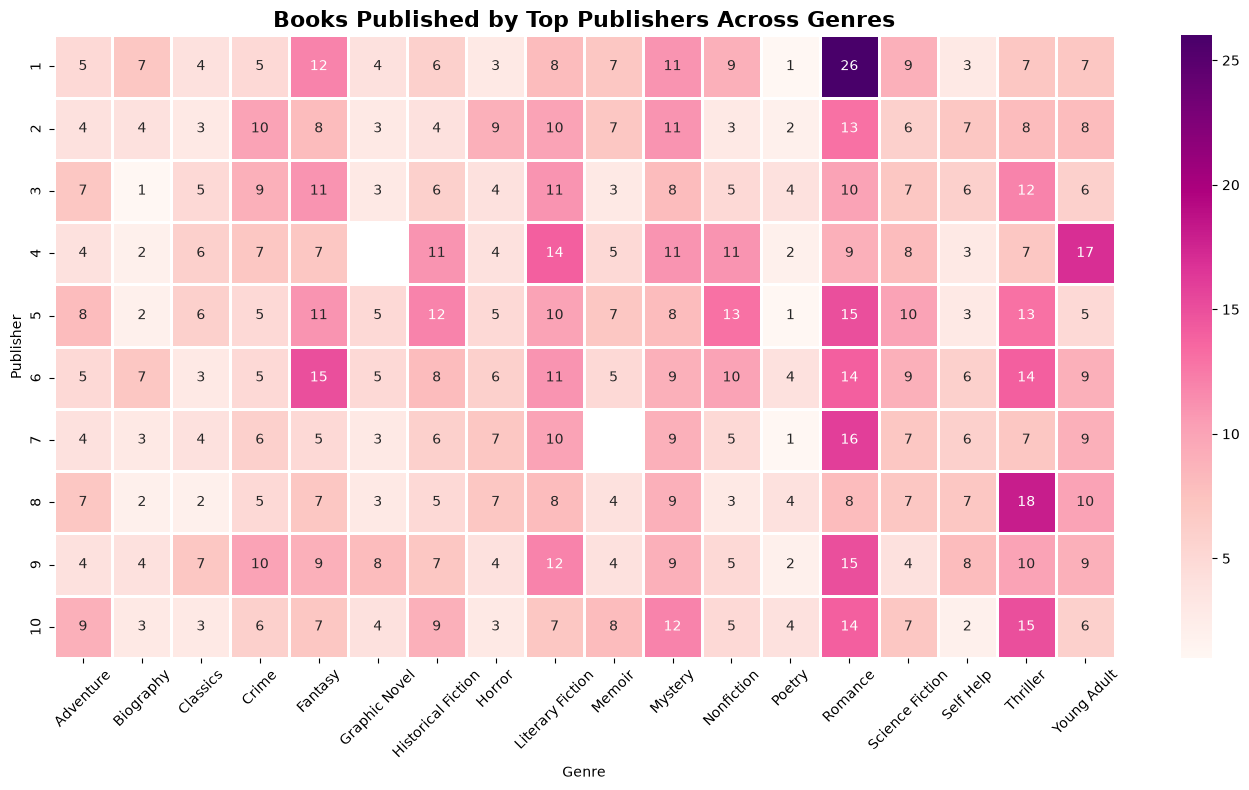

In [198]:
# for overall size of the chart plt.figure(figsize = (_,_))

plt.figure(figsize = (14,8))

# to make a heatmap - sns.heatmap(
#                                 data ,
#                                 annot = True/False                         -annotation -whether you want to write numbers alomg with colours in the map
#                                 cmap = colour of map
#                                 linewidhthss )

plt.figure(figsize=(14,8))

sns.heatmap(
    top_publishers,
    annot=True,
    fmt='.0f',          # use this if values are floats
    cmap='RdPu',        # beautiful light pink
    linewidths=0.9,
    linecolor='white',
    cbar=True
)

plt.title(
    "Books Published by Top Publishers Across Genres",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Genre")
plt.ylabel("Publisher")

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()  

## Question 4 - Which authors consistently write highly rated books? 
### Which authors have written multiple books and maintain a high average rating?

In [195]:
author_analysis = books.groupby('author_id').agg(
    book_count=('book_id', 'count'),
    avg_rating=('average_rating', 'mean')
)

# query- way for filtering a row sayiing show only those who satisfy the condition 
author_analysis  = author_analysis.query("book_count>=5")

author_analysis

,book_count,avg_rating
author_id,,
1,10,4.101000
2,11,4.150000
3,5,3.768000
4,10,3.900000
5,7,3.961429
...,...,...
3996,7,3.698571
3997,5,4.126000
3998,6,4.105000


In [219]:
top_authors = author_analysis.sort_values(
    by='author_id',
    ascending=True
).head(10).reset_index()

top_authors

,author_id,book_count,avg_rating
0,272,10,4.685000
1,669,8,4.688750
2,739,9,4.668889
3,917,5,4.782000
4,1099,8,4.640000
5,1291,9,4.670000
6,1854,6,4.723333
7,2139,7,4.724286
8,3561,11,4.690000
9,3758,8,4.718750


<Figure size 1400x800 with 0 Axes>

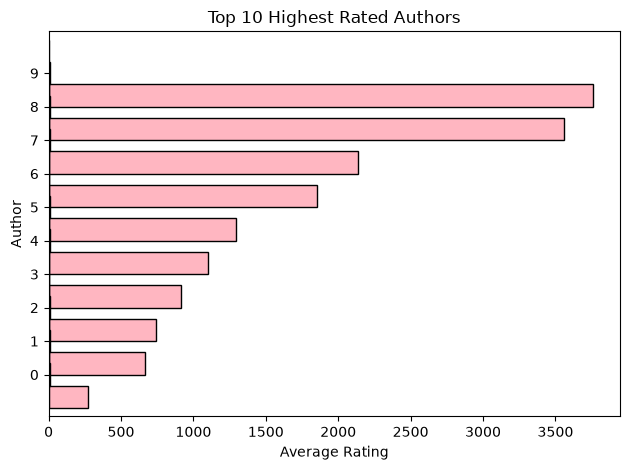

In [222]:
plt.figure(figsize=(14,8))

top_authors.plot(kind = 'barh' ,legend=False ,  color='lightpink', edgecolor='black' , width =2)
plt.title("Top 10 Highest Rated Authors")
plt.xlabel("Average Rating")

plt.ylabel("Author")
plt.tight_layout()
plt.show()

## Question 5 - Which authors write across the widest variety of genres?


In [234]:
# here to see various varities of genres for authors we use 'nunique' it counts the number of rows with unique values.

In [230]:
author_genres = books.groupby('author_id').agg(
    genre_count=('genre', 'nunique'),
    book_count=('book_id', 'count'),
    avg_rating=('average_rating', 'mean')
)

author_genres

,genre_count,book_count,avg_rating
author_id,,,
1,5,10,4.101000
2,10,11,4.150000
3,5,5,3.768000
4,8,10,3.900000
5,7,7,3.961429
...,...,...,...
3996,5,7,3.698571
3997,5,5,4.126000
3998,5,6,4.105000


In [241]:
# sort_values(by=['genre_count','avg_rating']) - means that first sort values via genre_count if it is same check avg rating
author_genre_top = author_genres.sort_values(by =['genre_count' , 'avg_rating'] , ascending=False).head(10)
author_genre_top

# we also want authors with multiple books so 
author_genre_top  = author_genre_top.query('book_count>=5')
author_genre_top

,genre_count,book_count,avg_rating
author_id,,,
3047,14,21,3.972857
1260,12,13,4.616923
788,12,16,4.276875
2295,12,17,4.250000
2251,12,17,4.159412
3295,12,13,4.013846
276,12,17,3.963529
857,12,15,3.790667
470,12,14,3.735714


In [242]:
# for only author and genre

author_genre = books.groupby('author_id').agg(
    genre_count=('genre', 'nunique'),
)

author_genre.head(3)

,genre_count
author_id,
1,5
2,10
3,5


C:\Users\annej\AppData\Local\Temp\ipykernel_29368\2145288756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


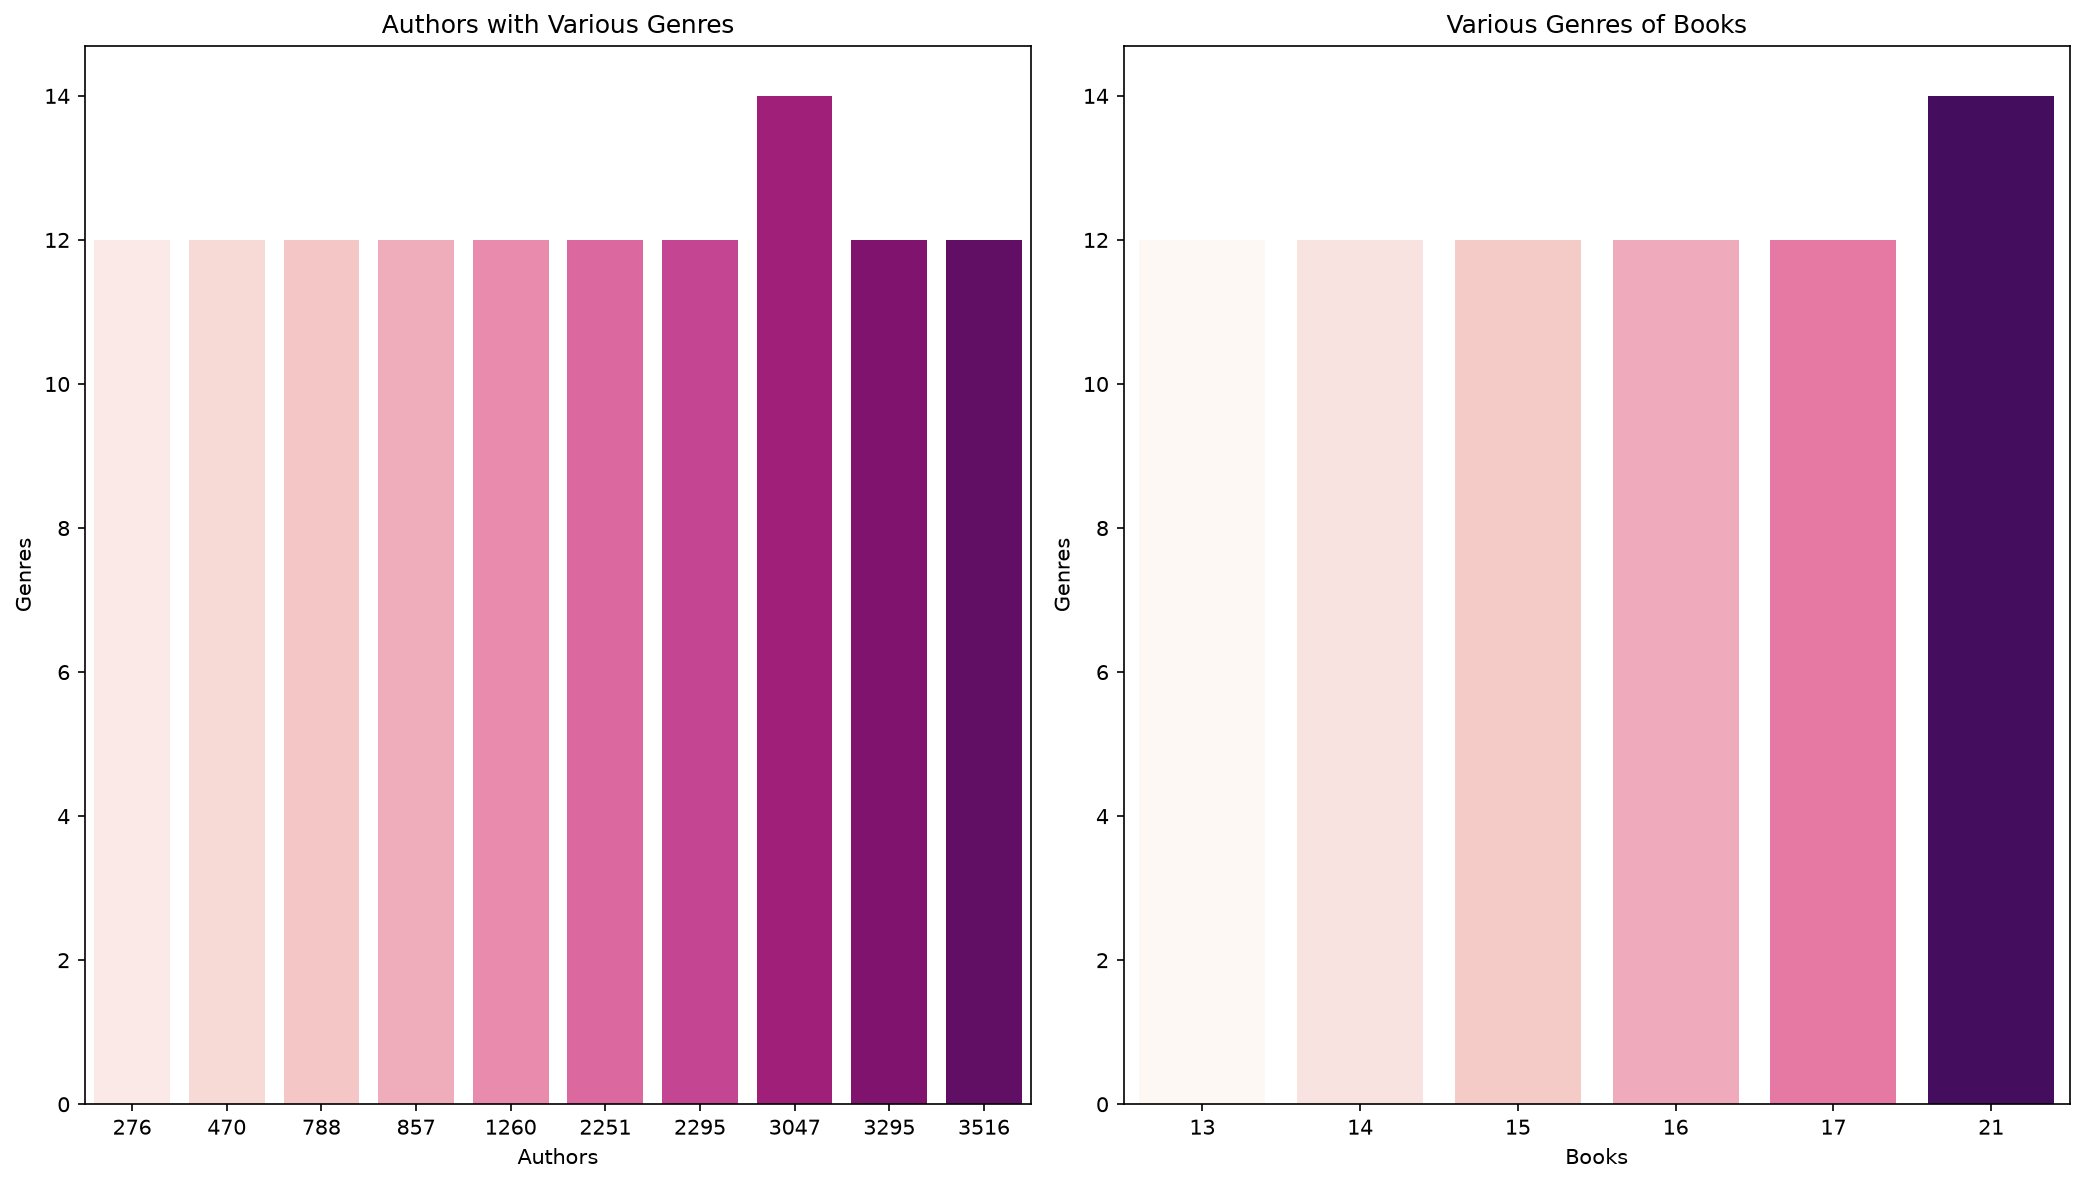

In [252]:
fig, ax = plt.subplots(1,2 ,figsize=(14,8) ,dpi=150)

sns.barplot(
    data=author_genre_top.reset_index(),
    x='author_id',
    y='genre_count',
    legend =False,
    ax=ax[0],
    palette='RdPu',
    dodge=False
)
ax[0].set_title("Authors with Various Genres")
ax[0].set_xlabel("Authors")
ax[0].set_ylabel("Genres")

sns.barplot(
    data=author_genre_top.reset_index(),
    x='book_count',
    y='genre_count',
    legend =False,
    ax=ax[1],
    hue='book_count',
    palette='RdPu',
    dodge=False
)
ax[1].set_title("Various Genres of Books")
ax[1].set_xlabel("Books")
ax[1].set_ylabel("Genres")

plt.tight_layout()
plt.show()

## Question 6 - Which publication years produced the highest-rated books?

In [253]:
year_analysis = books.groupby('publication_year').agg(
    book_count=('book_id', 'count'),
    avg_rating=('average_rating', 'mean'),
    avg_popularity=('popularity_score', 'mean')
)
year_analysis

,book_count,avg_rating,avg_popularity
publication_year,,,
1850,5,4.174000,51.600000
1851,2,4.155000,51.500000
1852,7,4.357143,58.285714
1853,3,3.980000,80.333333
1854,9,4.146667,56.666667
...,...,...,...
2021,600,4.025967,85.443333
2022,567,3.999647,84.989418
2023,489,3.957628,85.801636


In [255]:
year_analysis = year_analysis.query("book_count >= 20")
year_analysis = year_analysis.sort_index().head(10)
year_analysis

,book_count,avg_rating,avg_popularity
publication_year,,,
1969,20,4.128500,73.650000
1970,33,4.007576,67.696970
1971,20,4.121500,83.350000
1973,33,4.073333,68.090909
1974,44,4.034773,75.568182
1975,46,4.024783,73.043478
1976,53,3.956038,79.773585
1977,65,4.003231,72.861538
1978,65,4.077077,74.876923


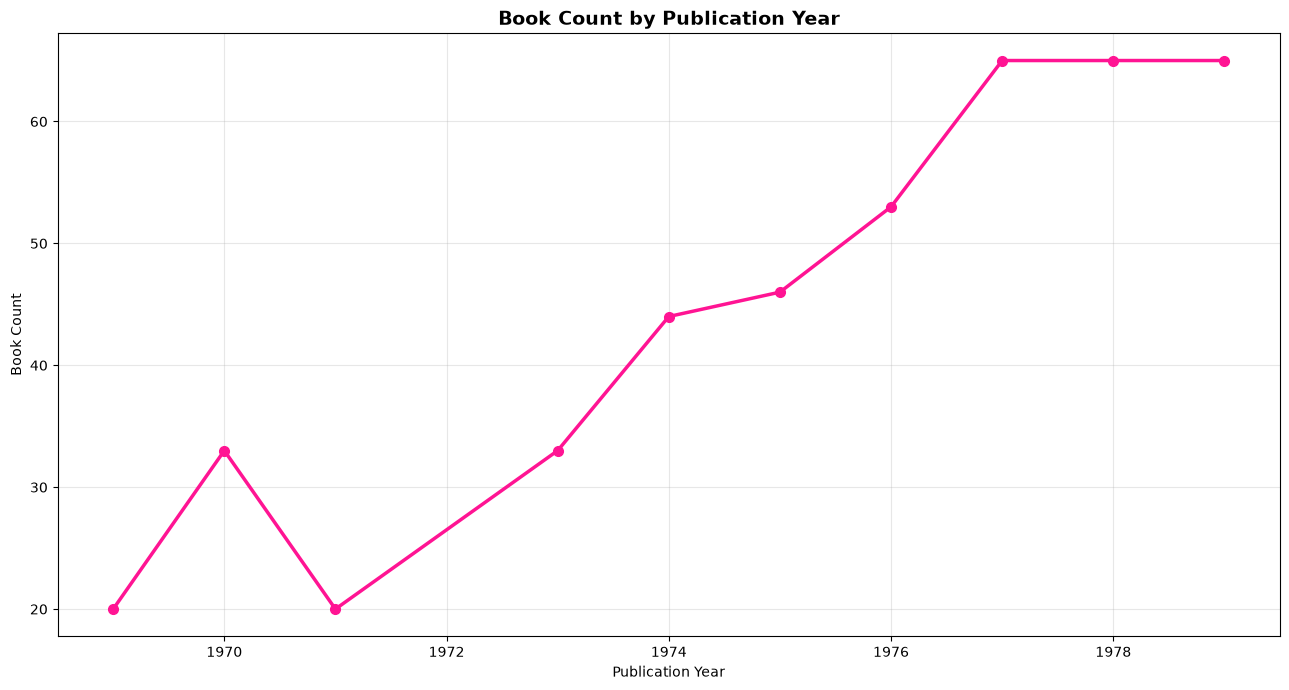

In [257]:
plt.figure(figsize=(13,7))

year_analysis['book_count'].plot(kind='line' , color='deeppink', marker='o', linewidth=2.5, markersize=7 )

plt.title(
    "Book Count by Publication Year",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Publication Year")
plt.ylabel("Book Count")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

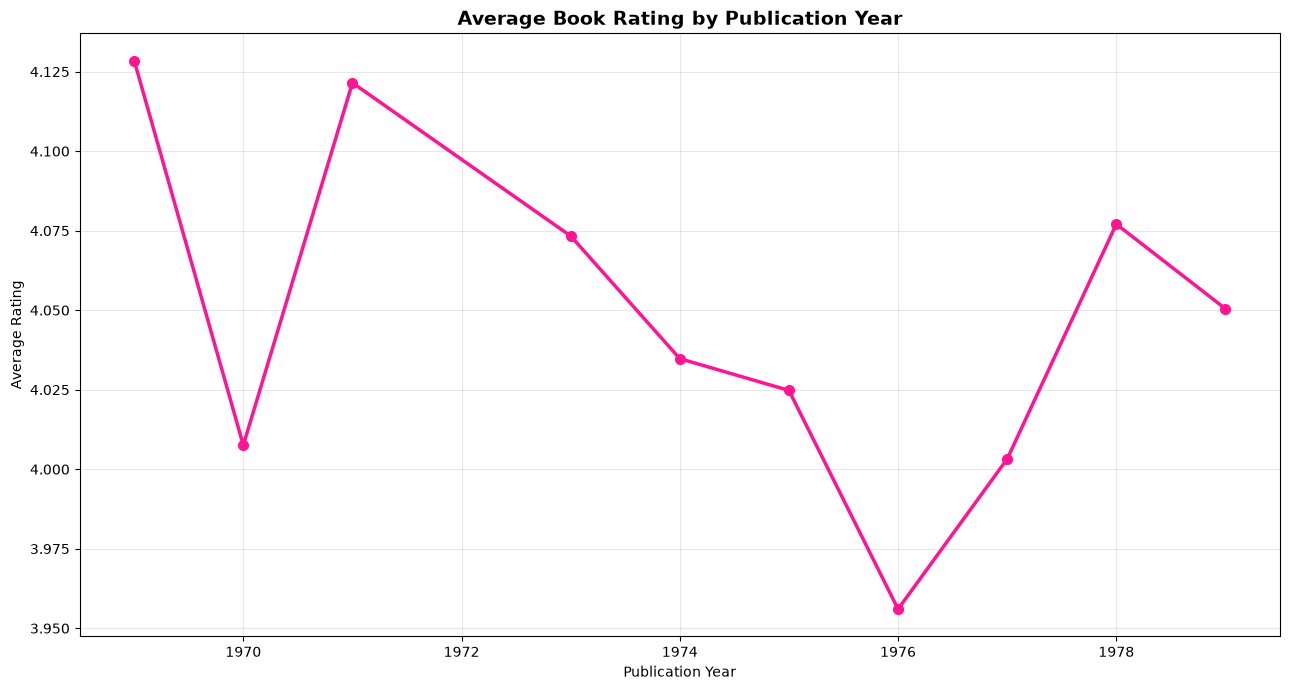

In [258]:
plt.figure(figsize=(13,7))

year_analysis['avg_rating'].plot(kind='line' , color='deeppink', marker='o', linewidth=2.5, markersize=7 )

plt.title(
    "Average Book Rating by Publication Year",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Publication Year")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Question 8 - Which genres have the most consistent ratings?

In [260]:
genre_consistency = books.groupby('genre').agg(
    book_count=('book_id','count'),
    avg_rating=('average_rating','mean'),
    rating_std=('average_rating','std')
)

genre_consistency

,book_count,avg_rating,rating_std
genre,,,
Adventure,1288,3.974542,0.327772
Biography,768,4.090898,0.311809
Classics,776,4.167191,0.325746
Crime,1611,3.943271,0.321117
Fantasy,2449,4.089098,0.318523
Graphic Novel,849,3.984676,0.314408
Historical Fiction,1837,4.155983,0.319518
Horror,1312,3.835755,0.322095
Literary Fiction,2062,4.065946,0.321008


In [261]:
genre_consistency = genre_consistency.query("book_count >= 20")

In [263]:
#Lower standard deviation = more consistent ratings.

genre_consistency = genre_consistency.sort_values(
    by='rating_std',
    ascending=True
)

genre_consistency

,book_count,avg_rating,rating_std
genre,,,
Memoir,1065,4.131192,0.307782
Biography,768,4.090898,0.311809
Young Adult,2146,3.911426,0.313596
Graphic Novel,849,3.984676,0.314408
Poetry,571,3.861243,0.314460
Mystery,2436,3.995866,0.315872
Romance,3164,3.965310,0.316876
Thriller,2654,3.920874,0.317494
Science Fiction,1956,4.029652,0.317956


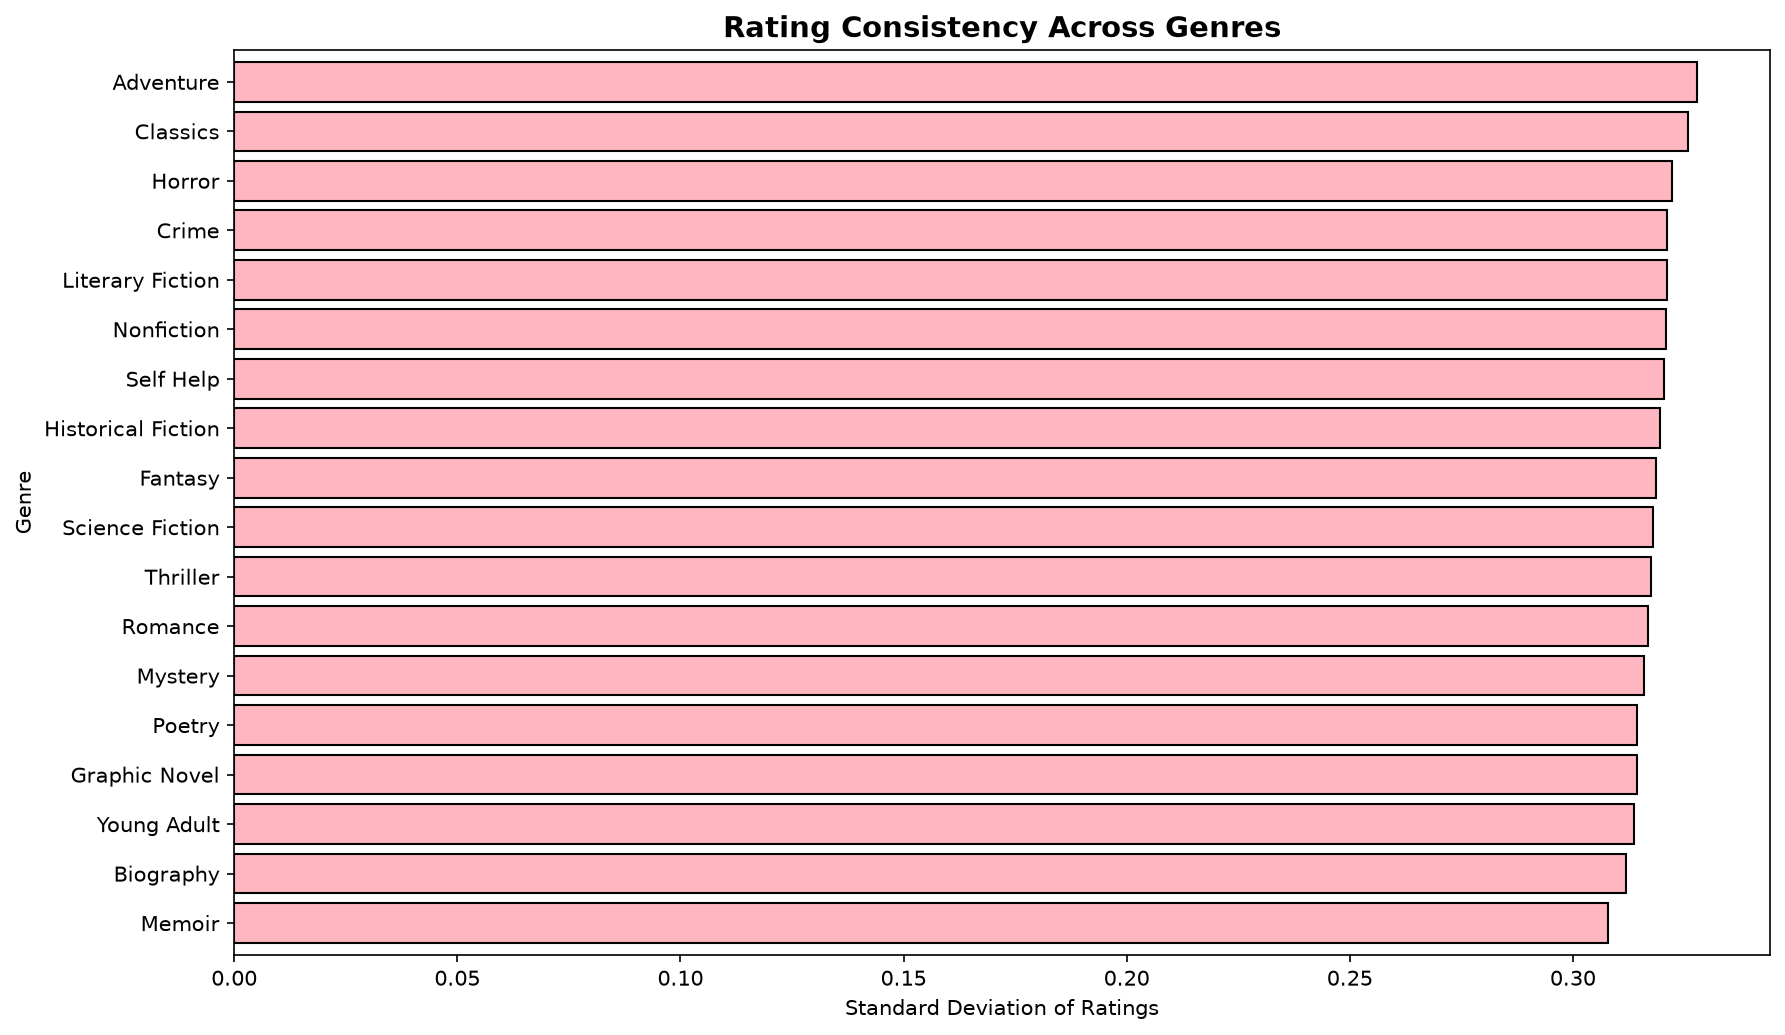

In [264]:
plt.figure(figsize=(12,7), dpi=150)

genre_consistency['rating_std'].plot(
    kind='barh',
    color='lightpink',
    edgecolor='black',
    width=0.8
)

plt.title(
    "Rating Consistency Across Genres",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Standard Deviation of Ratings")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()